<a href="https://colab.research.google.com/github/ajoy63776-lgtm/ML_project/blob/main/FackNews_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
fake = pd.read_csv("/content/Fake.csv", engine='python')
true = pd.read_csv("/content/True.csv", engine='python')

In [5]:
print(fake.head())

print(true.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [6]:
print(fake.info())

print(true.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12984 entries, 0 to 12983
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    12984 non-null  object
 1   text     12983 non-null  object
 2   subject  12983 non-null  object
 3   date     12983 non-null  object
dtypes: object(4)
memory usage: 405.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4532 entries, 0 to 4531
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    4532 non-null   object
 1   text     4531 non-null   object
 2   subject  4531 non-null   object
 3   date     4531 non-null   object
dtypes: object(4)
memory usage: 141.8+ KB
None


In [7]:
fake["label"] = 0
true["label"] = 1

In [8]:
data = pd.concat([fake, true], axis=0)

print(data.shape)

(17516, 5)


In [9]:
data = data.sample(frac=1, random_state=42)

data.reset_index(drop=True, inplace=True)

In [14]:
data["content"] = data["title"].fillna('') + " " + data["text"].fillna('')

In [11]:
X = data["content"]
y = data["label"]

In [16]:
# Ensure all values in X are strings and fill any potential remaining NaNs
X = X.fillna('')

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
vectorizer = TfidfVectorizer(stop_words='english',
                             max_df=0.7)

X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

In [20]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [21]:
prediction = model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

Accuracy : 0.9851598173515982


In [23]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2604
           1       0.98      0.96      0.97       900

    accuracy                           0.99      3504
   macro avg       0.98      0.98      0.98      3504
weighted avg       0.99      0.99      0.99      3504



In [24]:
cm = confusion_matrix(y_test, prediction)

print(cm)

[[2586   18]
 [  34  866]]


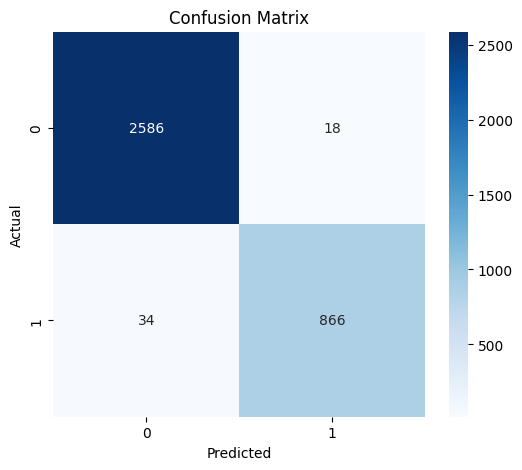

In [25]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [30]:
news = input("Enter News: ")

news_vector = vectorizer.transform([news])

result = model.predict(news_vector)

if result[0] == 0:
    print("Fake News")
else:
    print("True News")

Enter News: lion is the king of jungal
Fake News
